# Enviroment Setup

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/SARIMA'

# Processed Data

In [ ]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

# Model Definition - SARIMA

In [ ]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error — robust to zero values."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return float('nan')
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def run_sarima_prediction(df, dataset_name, dataset_code, dataset_number, split_days=90, n_splits=3, order=(1,0,1), seasonal_order=(1,1,1,7), VIS_DIR='.'):
    """
    Train SARIMA with rolling-origin validation.
    Plots are generated ONLY for the best split (lowest sMAPE).
    """
    print(f"\n{'='*100}")
    print(f"SARIMA PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # dropping NaN rows in target
    df_valid = df[df['total_tonnes'].notna()].reset_index(drop=True)
    print(f"Total rows: {len(df)}, Valid (non-NaN target): {len(df_valid)}")

    # ============================================================
    # ROLLING-ORIGIN VALIDATION
    # ============================================================
    split_results = []
    total_needed = split_days * n_splits

    if len(df_valid) < total_needed + 100:
        print(f"WARNING: Not enough data for {n_splits} splits of {split_days} days.")
        print(f"Reducing to 2 splits.")
        n_splits = 2

    print(f"\nRolling-origin validation: {n_splits} splits of {split_days} days each")

    best_smape = float('inf')
    best_split_data = None

    for split_idx in range(n_splits):
        offset = (n_splits - 1 - split_idx) * split_days
        if offset == 0:
            train = df_valid.iloc[:-split_days]
            test = df_valid.iloc[-split_days:]
        else:
            train = df_valid.iloc[:-(offset + split_days)]
            test = df_valid.iloc[-(offset + split_days):-offset]

        print(f"\n--- Split {split_idx+1}/{n_splits} ---")
        print(f"Train: {len(train)} days ({train['date'].min().date()} → {train['date'].max().date()})")
        print(f"Test:  {len(test)} days ({test['date'].min().date()} → {test['date'].max().date()})")

        # model fit
        try:
            model = SARIMAX(
                train['total_tonnes'],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False, maxiter=200)
        except Exception as e:
            print(f"ERROR fitting SARIMA: {e}")
            print("Trying fallback SARIMA(1,1,0)(1,1,0,7)...")
            model = SARIMAX(
                train['total_tonnes'],
                order=(1,1,0),
                seasonal_order=(1,1,0,7),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False, maxiter=200)

        # forecast
        forecast = fitted.forecast(steps=len(test))
        forecast = forecast.clip(lower=0)

        y_true = test['total_tonnes'].values
        y_pred = forecast.values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape_val = smape(y_true, y_pred)

        split_results.append({'mae': mae, 'rmse': rmse, 'smape': smape_val})
        print(f"MAE: {mae:.2f}t | RMSE: {rmse:.2f}t | sMAPE: {smape_val:.2f}%")

        # best split tracking
        if smape_val < best_smape:
            best_smape = smape_val
            best_split_data = {
                'split_idx': split_idx + 1,
                'train': train,
                'test': test,
                'y_true': y_true,
                'y_pred': y_pred,
                'mae': mae,
                'rmse': rmse,
                'smape': smape_val,
                'aic': fitted.aic
            }


    # ============================================================
    # AVERAGE METRICS ACROSS SPLITS
    # ============================================================
    avg_mae = np.mean([r['mae'] for r in split_results])
    avg_rmse = np.mean([r['rmse'] for r in split_results])
    avg_smape = np.mean([r['smape'] for r in split_results])

    print(f"\n--- AVERAGE ACROSS {n_splits} SPLITS ---")
    print(f"MAE:   {avg_mae:.2f} tonnes")
    print(f"RMSE:  {avg_rmse:.2f} tonnes")
    print(f"sMAPE: {avg_smape:.2f}%")
    print(f"Best split was Split {best_split_data['split_idx']} (sMAPE: {best_split_data['smape']:.2f}%)")


    # ============================================================
    # PLOT — BEST SPLIT ONLY
    # ============================================================
    train_plot = best_split_data['train']
    test_plot = best_split_data['test']
    y_true_plot = best_split_data['y_true']
    y_pred_plot = best_split_data['y_pred']


    # --- Plot 1X1: Actual vs Predicted (test period) - SARIMA ---
    fig, ax = plt.subplots(figsize=(16, 6))

    context = train_plot.iloc[-30:]
    ax.plot(context['date'], context['total_tonnes'], color='steelblue',
            linewidth=1, label='Training Data (last 30 days)')
    ax.plot(test_plot['date'], y_true_plot, color='steelblue',
            linewidth=1.5, label='Actual (Test)')
    ax.plot(test_plot['date'], y_pred_plot, color='red',
            linewidth=1.5, linestyle='--', label='SARIMA Forecast')
    ax.axvline(x=test_plot['date'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

    ax.set_title(f"SARIMA Forecast vs Actual — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95,
            f"Best Split Metrics:\nMAE: {best_split_data['mae']:.2f}t\nRMSE: {best_split_data['rmse']:.2f}t\nsMAPE: {best_split_data['smape']:.1f}%",
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'1{dataset_number}1_sarima_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 1X2: Zoom on first 30 days of test - SARIMA ---
    fig, ax = plt.subplots(figsize=(14, 5))
    zoom_days = min(30, split_days)
    ax.plot(test_plot['date'].iloc[:zoom_days], y_true_plot[:zoom_days],
            color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')
    ax.plot(test_plot['date'].iloc[:zoom_days], y_pred_plot[:zoom_days],
            color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='SARIMA')
    ax.set_title(f"SARIMA Forecast Zoom — {dataset_name} (Best Split: #{best_split_data['split_idx']})",
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'1{dataset_number}2_sarima_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'dataset': dataset_name,
        'model': 'SARIMA',
        'mae': round(avg_mae, 2),
        'rmse': round(avg_rmse, 2),
        'smape': round(avg_smape, 2),
        'n_splits': n_splits,
        'split_days': split_days,
        'best_split_aic': round(best_split_data['aic'], 2),
        'split_details': split_results
    }

# Model Prediction - SARIMA


SARIMA PREDICTION — Boralesgamuwa UC (Sri Lanka)
Total rows: 2527, Valid (non-NaN target): 2387

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 2117 days (2012-01-31 → 2018-03-26)
Test:  90 days (2018-03-28 → 2018-06-28)
MAE: 9.14t | RMSE: 11.24t | sMAPE: 34.13%

--- Split 2/3 ---
Train: 2207 days (2012-01-31 → 2018-06-28)
Test:  90 days (2018-06-29 → 2018-09-29)
MAE: 6.59t | RMSE: 8.57t | sMAPE: 27.70%

--- Split 3/3 ---
Train: 2297 days (2012-01-31 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
MAE: 7.10t | RMSE: 9.07t | sMAPE: 27.72%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   7.61 tonnes
RMSE:  9.63 tonnes
sMAPE: 29.85%
Best split was Split 2 (sMAPE: 27.70%)


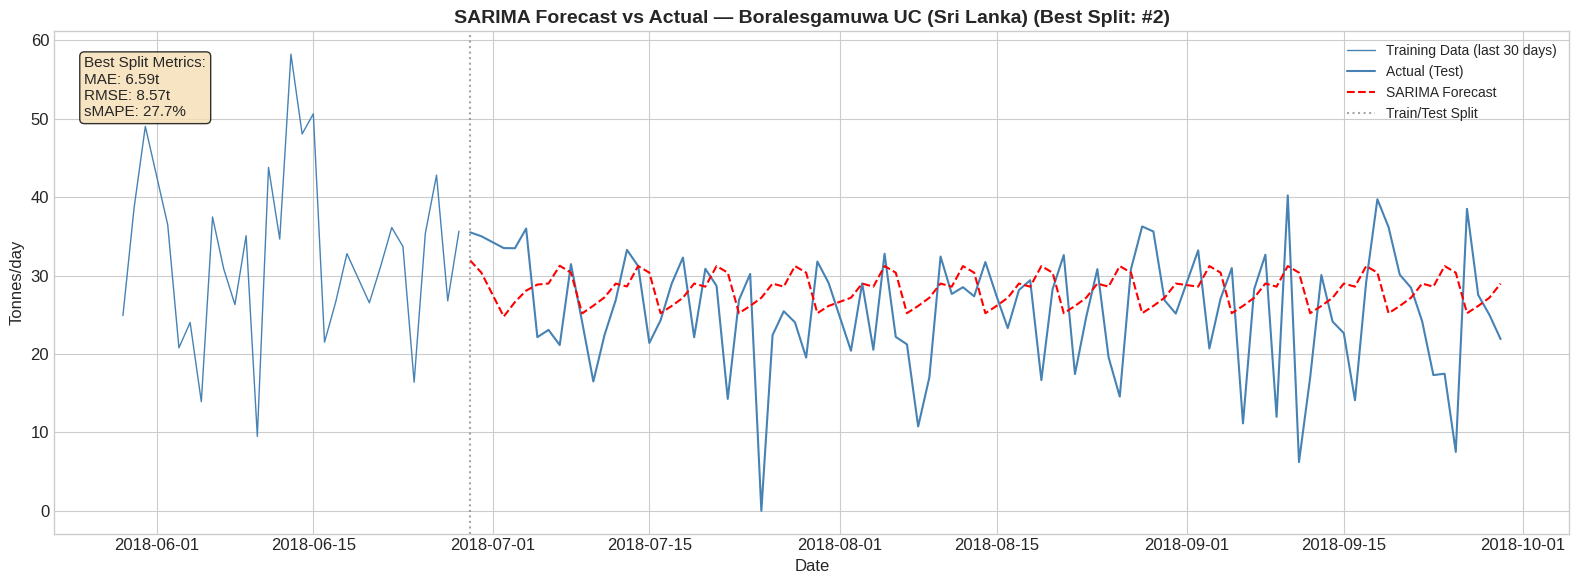

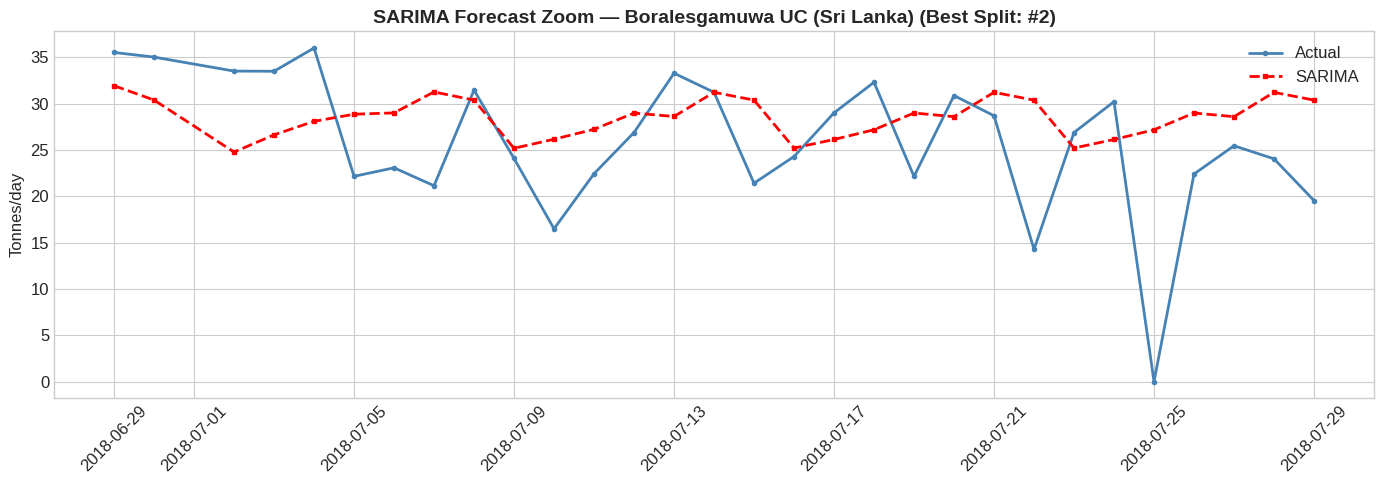


SARIMA PREDICTION — Dehiwala MC (Sri Lanka)
Total rows: 1431, Valid (non-NaN target): 1403

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1133 days (2012-01-31 → 2015-03-28)
Test:  90 days (2015-03-29 → 2015-07-01)
MAE: 31.59t | RMSE: 39.20t | sMAPE: 22.06%

--- Split 2/3 ---
Train: 1223 days (2012-01-31 → 2015-07-01)
Test:  90 days (2015-07-02 → 2015-09-29)
MAE: 37.22t | RMSE: 51.21t | sMAPE: 31.55%

--- Split 3/3 ---
Train: 1313 days (2012-01-31 → 2015-09-29)
Test:  90 days (2015-09-30 → 2015-12-31)
MAE: 39.83t | RMSE: 48.57t | sMAPE: 31.21%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   36.21 tonnes
RMSE:  46.33 tonnes
sMAPE: 28.27%
Best split was Split 1 (sMAPE: 22.06%)


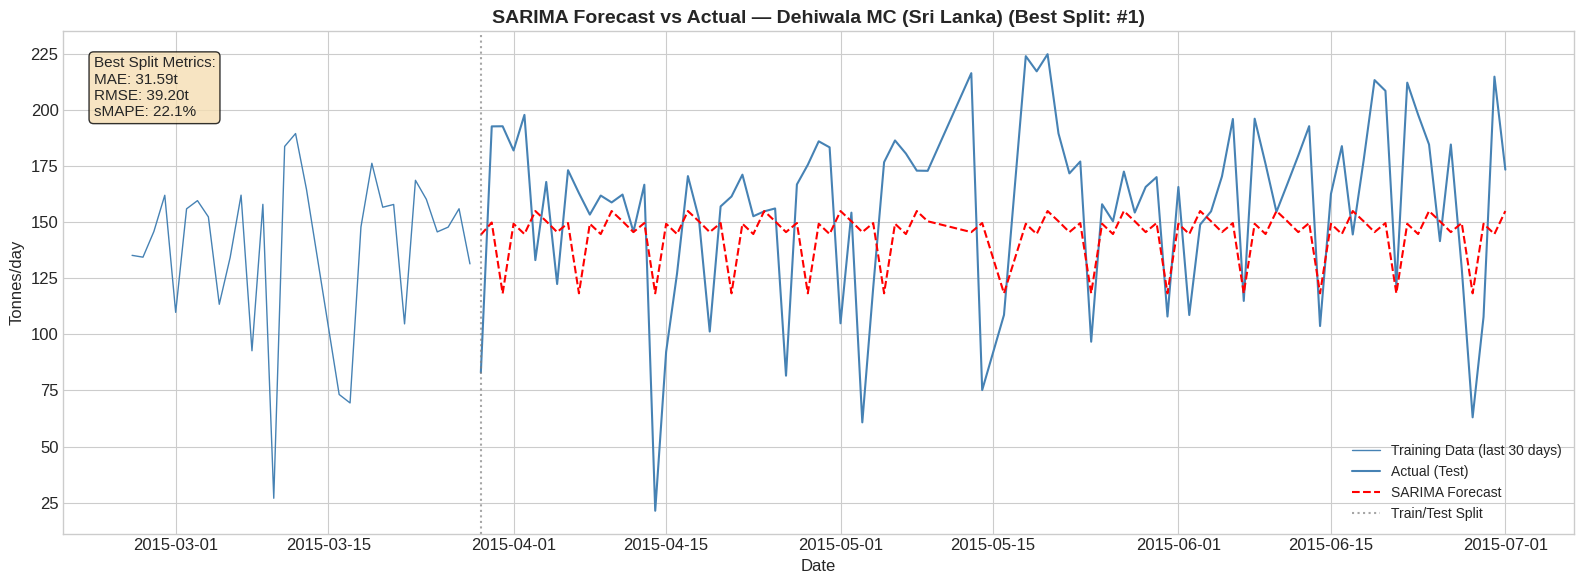

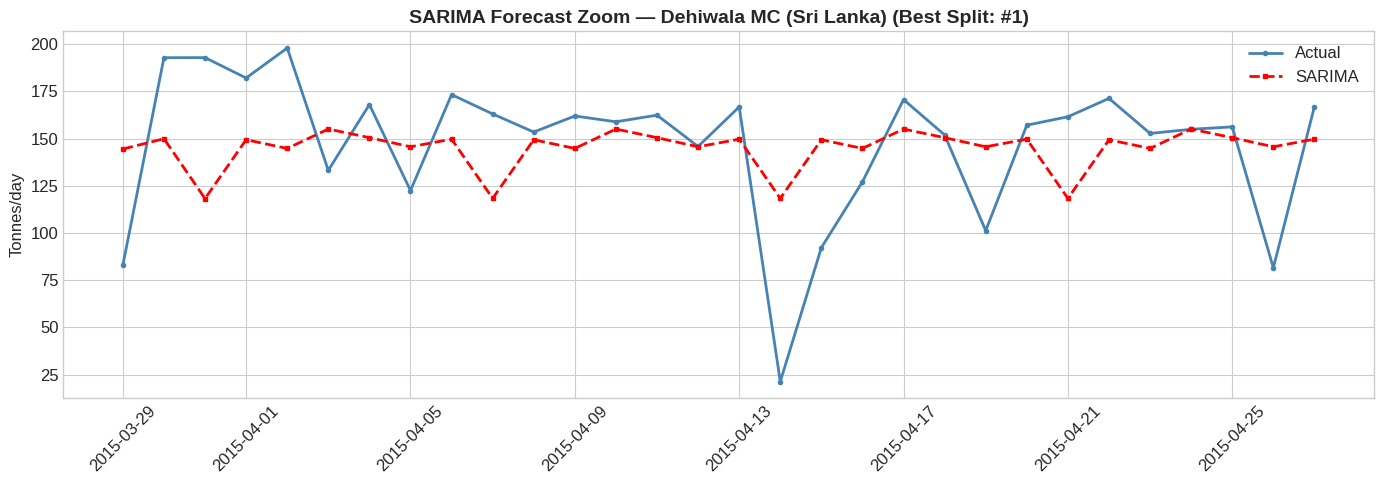


SARIMA PREDICTION — Homagama PS (Sri Lanka)
Total rows: 2526, Valid (non-NaN target): 2038

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1768 days (2012-02-02 → 2018-03-21)
Test:  90 days (2018-03-22 → 2018-06-25)
MAE: 12.26t | RMSE: 16.09t | sMAPE: 35.65%

--- Split 2/3 ---
Train: 1858 days (2012-02-02 → 2018-06-25)
Test:  90 days (2018-06-26 → 2018-09-29)
MAE: 9.53t | RMSE: 12.10t | sMAPE: 30.86%

--- Split 3/3 ---
Train: 1948 days (2012-02-02 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
MAE: 11.08t | RMSE: 14.87t | sMAPE: 31.63%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   10.96 tonnes
RMSE:  14.35 tonnes
sMAPE: 32.71%
Best split was Split 2 (sMAPE: 30.86%)


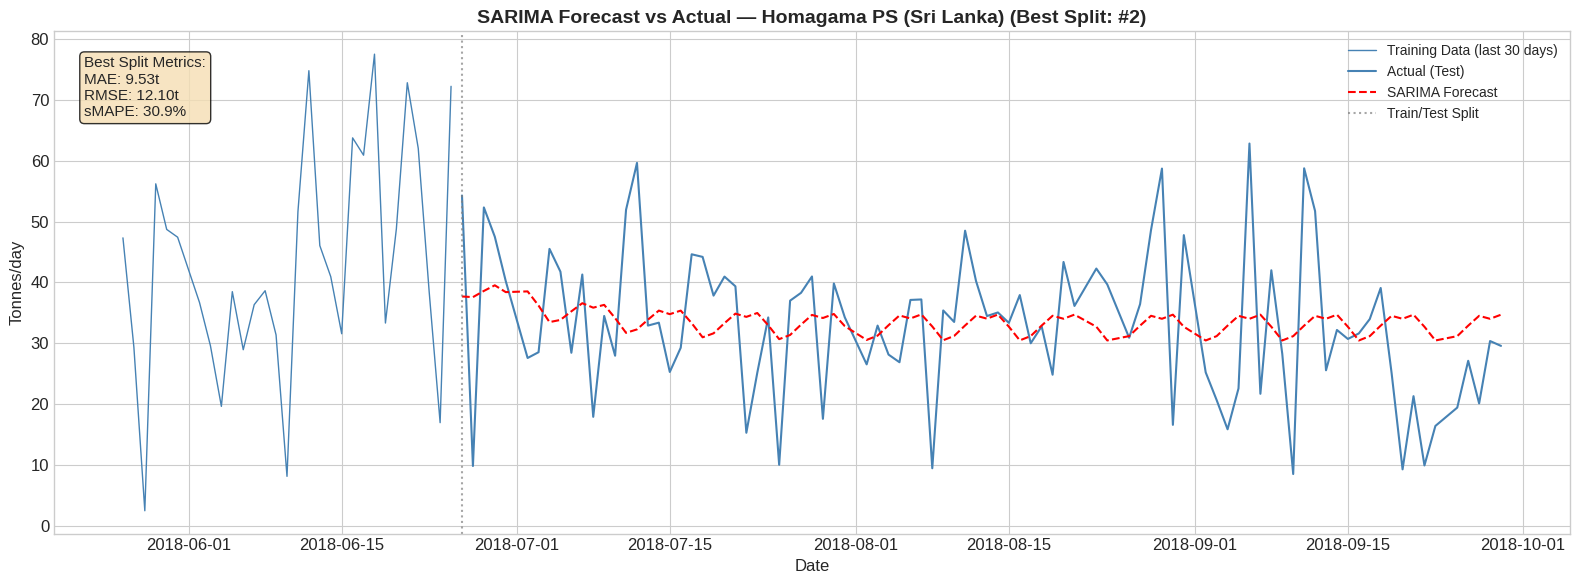

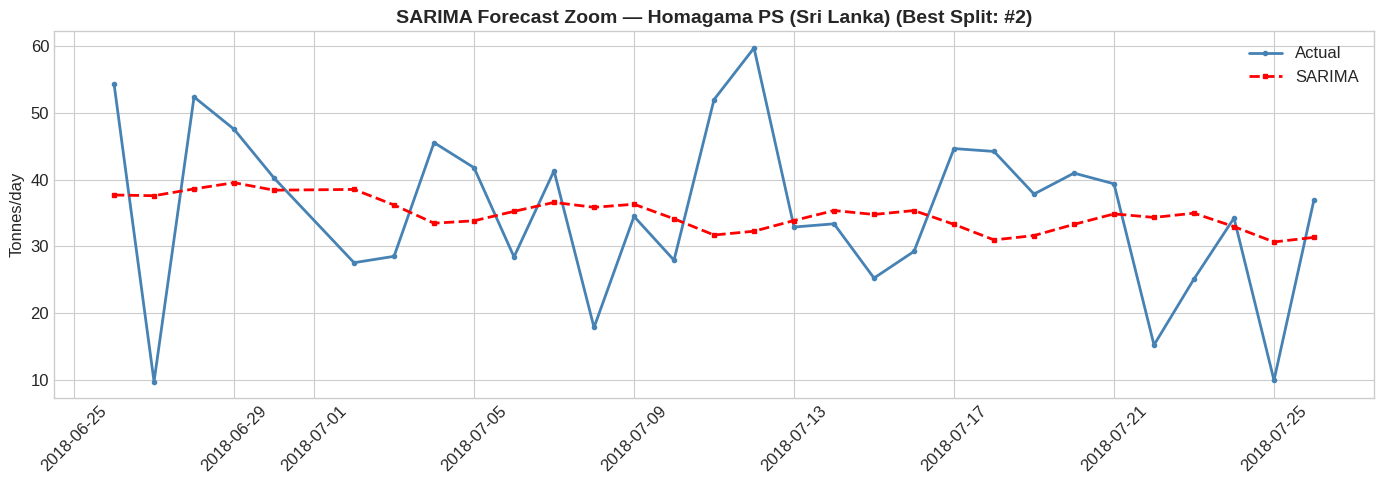


SARIMA PREDICTION — Moratuwa MC (Sri Lanka)
Total rows: 1411, Valid (non-NaN target): 1278

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1008 days (2015-01-31 → 2018-02-26)
Test:  90 days (2018-02-27 → 2018-06-03)
MAE: 18.36t | RMSE: 24.96t | sMAPE: 26.88%

--- Split 2/3 ---
Train: 1098 days (2015-01-31 → 2018-06-03)
Test:  90 days (2018-06-04 → 2018-09-08)
MAE: 15.92t | RMSE: 20.95t | sMAPE: 22.81%

--- Split 3/3 ---
Train: 1188 days (2015-01-31 → 2018-09-08)
Test:  90 days (2018-09-09 → 2018-12-11)
MAE: 16.90t | RMSE: 22.12t | sMAPE: 25.93%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   17.06 tonnes
RMSE:  22.68 tonnes
sMAPE: 25.21%
Best split was Split 2 (sMAPE: 22.81%)


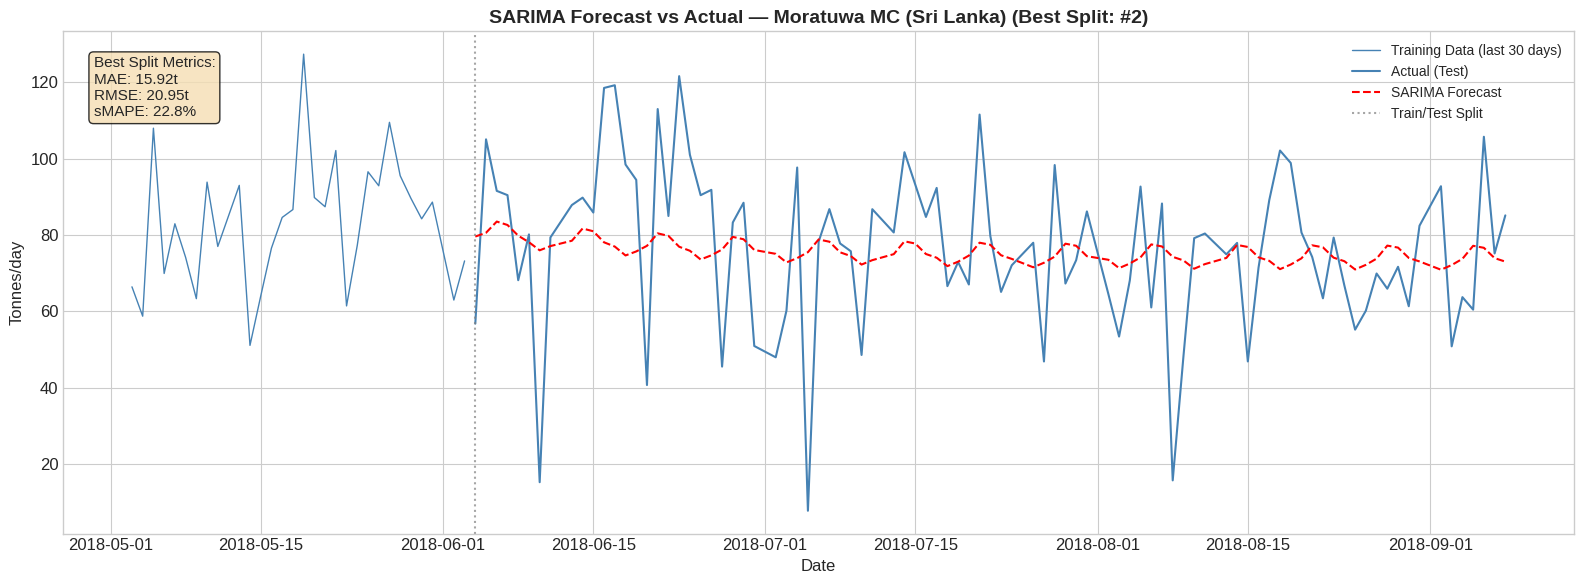

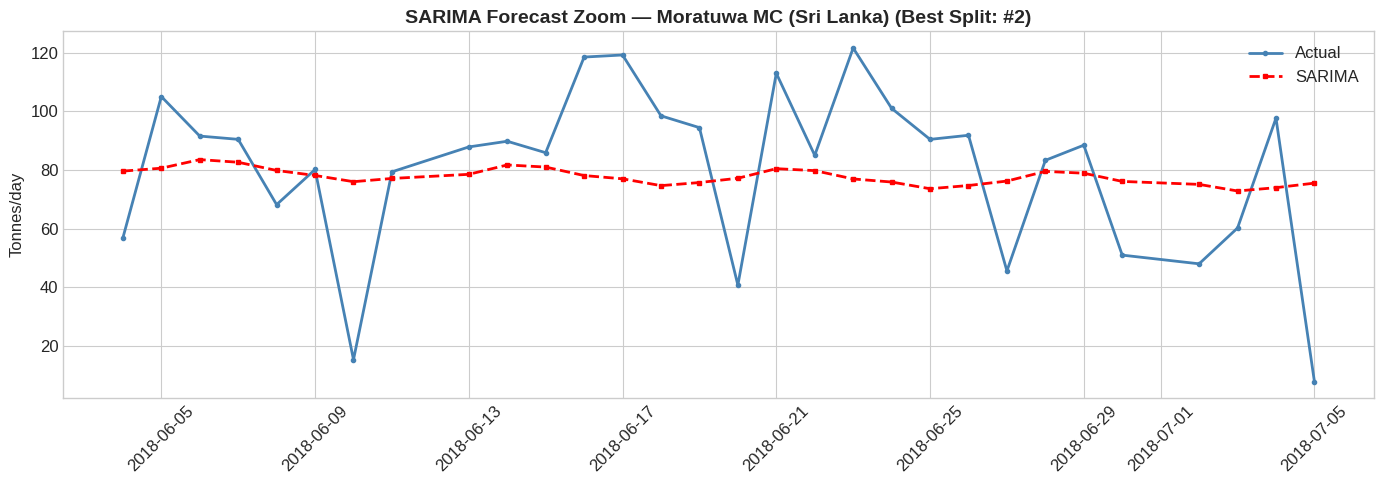


SARIMA PREDICTION — Austin TX (USA)
Total rows: 5813, Valid (non-NaN target): 5803

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 5533 days (2005-02-01 → 2020-04-04)
Test:  90 days (2020-04-05 → 2020-07-03)
MAE: 171.99t | RMSE: 238.06t | sMAPE: 39.38%

--- Split 2/3 ---
Train: 5623 days (2005-02-01 → 2020-07-03)
Test:  90 days (2020-07-04 → 2020-10-01)
MAE: 127.29t | RMSE: 174.04t | sMAPE: 40.94%

--- Split 3/3 ---
Train: 5713 days (2005-02-01 → 2020-10-01)
Test:  90 days (2020-10-02 → 2020-12-31)
MAE: 229.66t | RMSE: 471.29t | sMAPE: 50.68%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   176.31 tonnes
RMSE:  294.46 tonnes
sMAPE: 43.66%
Best split was Split 1 (sMAPE: 39.38%)


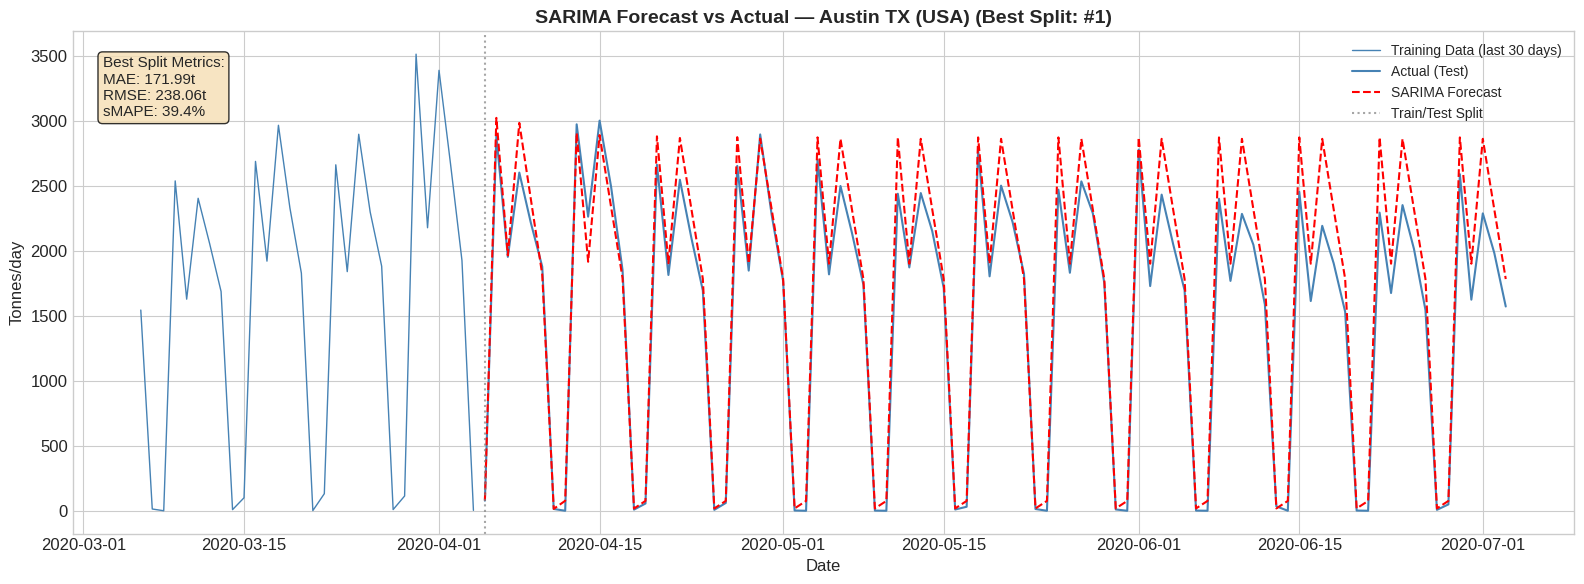

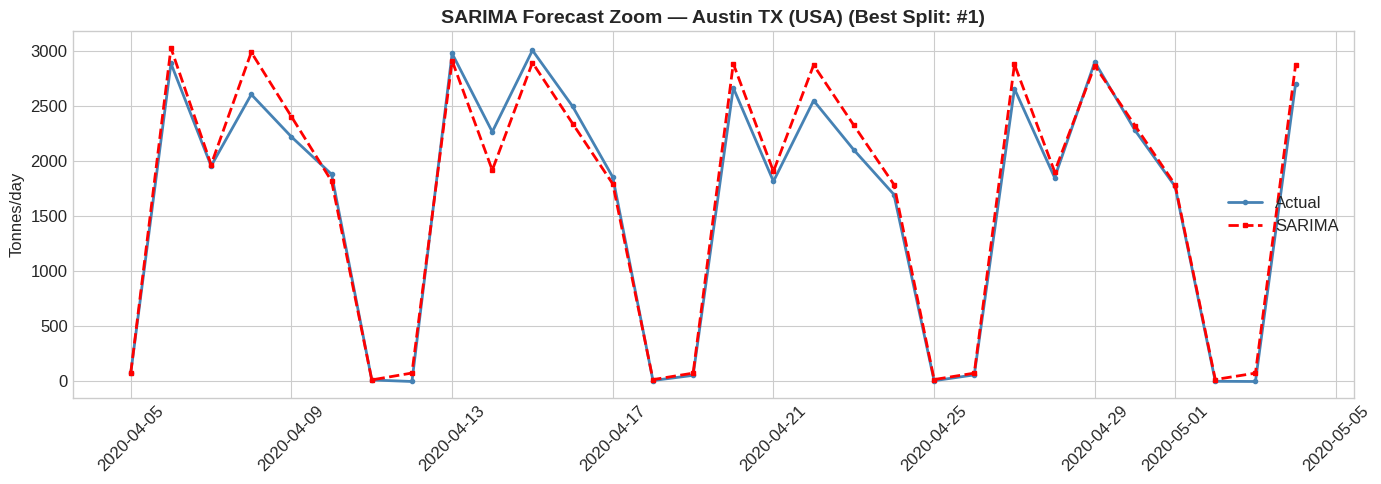


SARIMA PREDICTION — Ballarat (Australia)
Total rows: 4717, Valid (non-NaN target): 4703

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 4433 days (2001-02-01 → 2013-04-03)
Test:  90 days (2013-04-04 → 2013-07-02)
MAE: 11.86t | RMSE: 17.34t | sMAPE: 68.06%

--- Split 2/3 ---
Train: 4523 days (2001-02-01 → 2013-07-02)
Test:  90 days (2013-07-03 → 2013-10-01)
MAE: 10.75t | RMSE: 22.04t | sMAPE: 70.46%

--- Split 3/3 ---
Train: 4613 days (2001-02-01 → 2013-10-01)
Test:  90 days (2013-10-02 → 2013-12-31)
MAE: 22.46t | RMSE: 28.31t | sMAPE: 59.52%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   15.03 tonnes
RMSE:  22.56 tonnes
sMAPE: 66.01%
Best split was Split 3 (sMAPE: 59.52%)


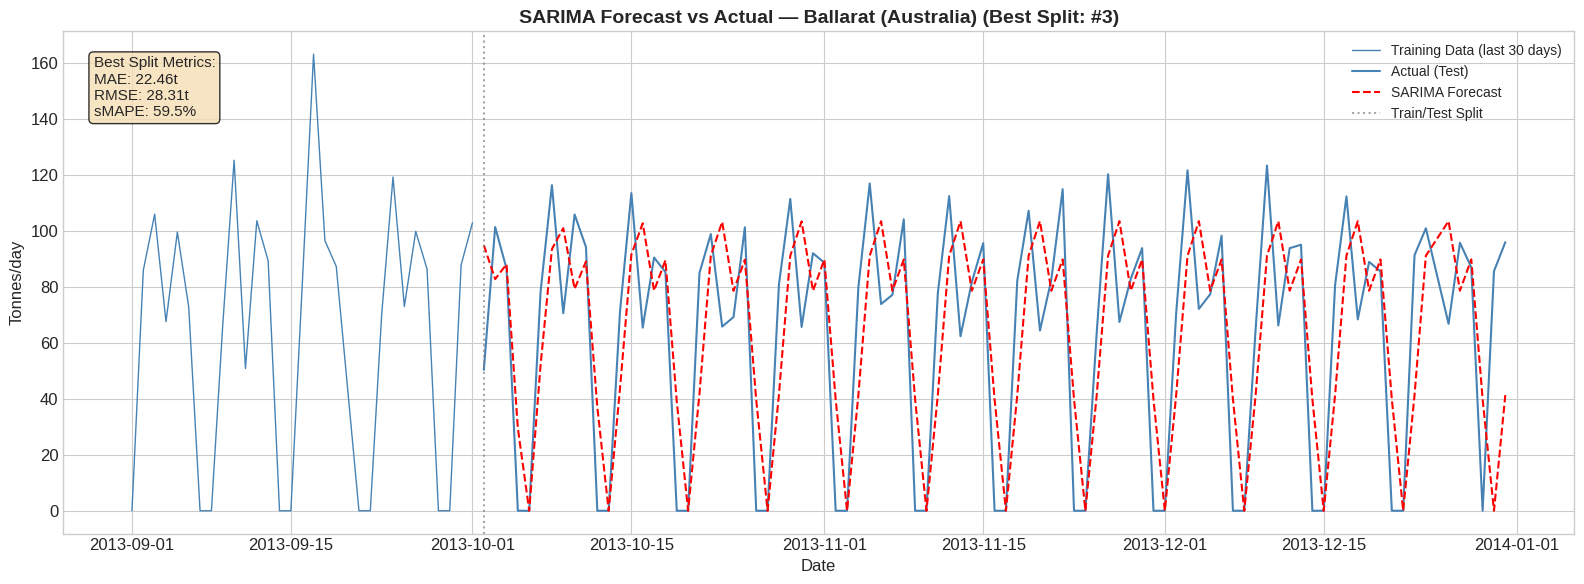

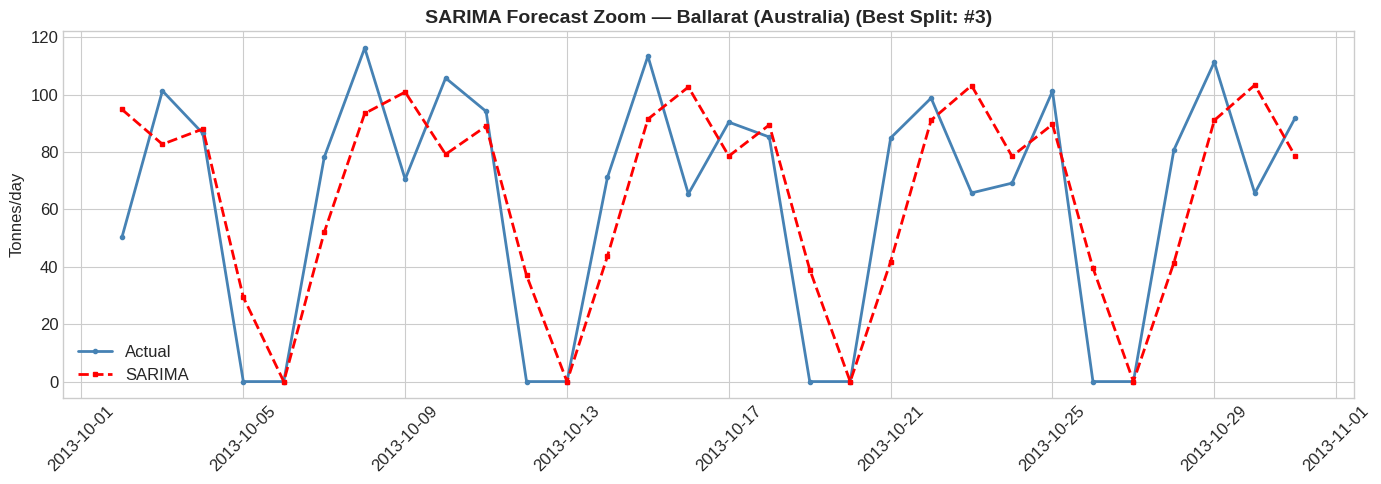

In [ ]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_sarima_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            split_days = 90,
            n_splits = 3,
            order = (1,0,1),         # d=0: ADF test confirmed stationarity
            seasonal_order = (1,1,1,7)  # s=7: weekly seasonality from ACF
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [ ]:
print("\n" + "=" * 100)
print("SARIMA RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\nValidation: Rolling-origin with {all_results[0]['n_splits']} splits of {all_results[0]['split_days']} days")
print(f"Metrics are AVERAGED across splits (except AIC which is from the Best Split).")
print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'sMAPE (%)':>9s} | {'Best AIC':>10s}")
print("-" * 100)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['smape']:>8.2f}% | {row['best_split_aic']:>10.2f}")

# average
print("-" * 100)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['smape'].mean():>8.2f}% |")

# per-split detail
print(f"\n--- Per-split details ---")
for _, row in results_df.iterrows():
    print(f"\n{row['dataset']}:")
    for j, s in enumerate(row['split_details']):
        print(f"  Split {j+1}: MAE={s['mae']:.2f}t, RMSE={s['rmse']:.2f}t, sMAPE={s['smape']:.2f}%")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'sarima_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/sarima_results.csv")


SARIMA RESULTS SUMMARY — ALL DATASETS

Validation: Rolling-origin with 3 splits of 90 days
Metrics are AVERAGED across splits (except AIC which is from the Best Split).

Dataset                        |  MAE (t) |  RMSE (t) | sMAPE (%) |   Best AIC
----------------------------------------------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     7.61 |      9.63 |    29.85% |   16531.52
Dehiwala MC (Sri Lanka)        |    36.21 |     46.33 |    28.27% |   10741.36
Homagama PS (Sri Lanka)        |    10.96 |     14.35 |    32.71% |   15119.04
Moratuwa MC (Sri Lanka)        |    17.06 |     22.68 |    25.21% |   10556.76
Austin TX (USA)                |   176.31 |    294.46 |    43.66% |   77696.44
Ballarat (Australia)           |    15.03 |     22.56 |    66.01% |   34883.34
----------------------------------------------------------------------------------------------------
AVERAGE                        |    43.86 |     68.33 |    37.62% |

--- P

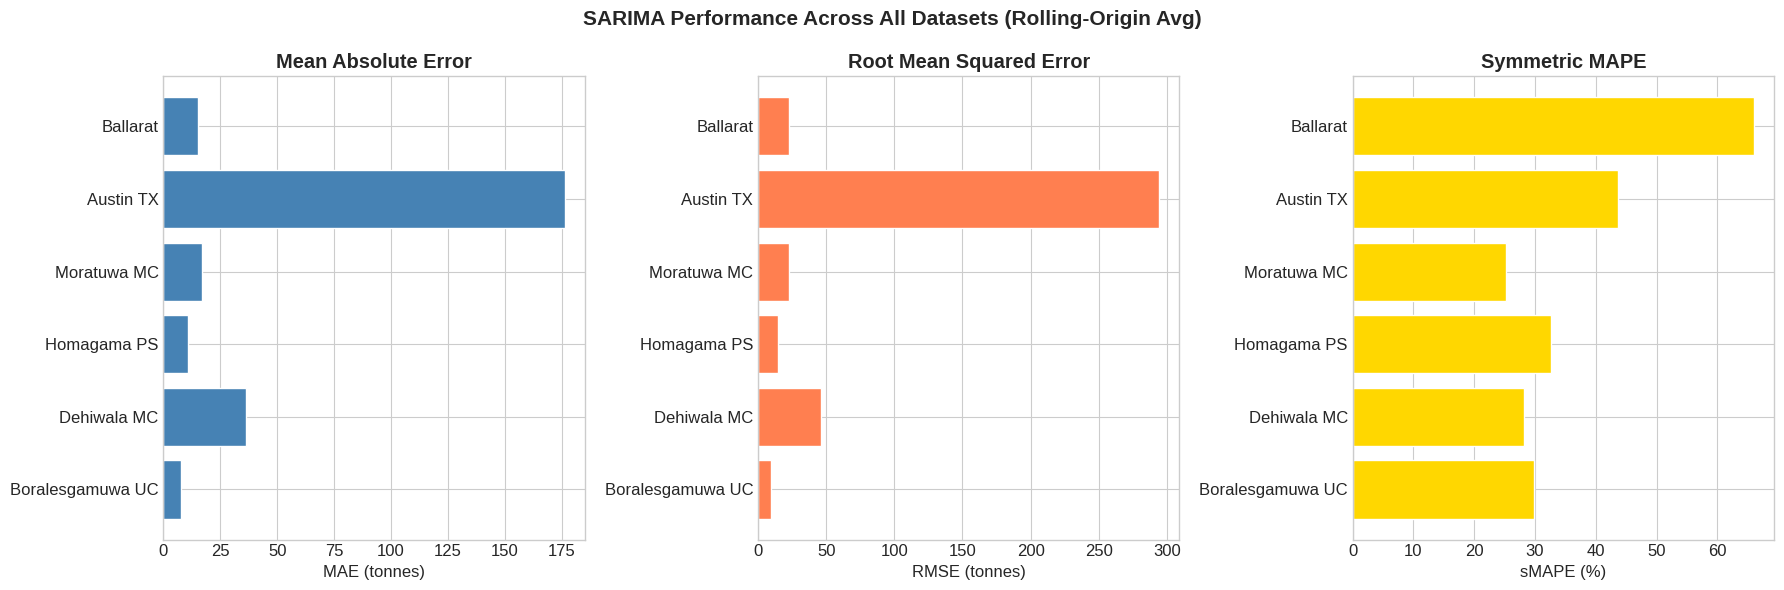

In [ ]:
# --- Plot: SARIMA Performance Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# sMAPE
axes[2].barh(short_names, results_df['smape'], color='gold', edgecolor='white')
axes[2].set_xlabel('sMAPE (%)')
axes[2].set_title('Symmetric MAPE', fontweight='bold')

plt.suptitle('SARIMA Performance Across All Datasets (Rolling-Origin Avg)', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '101_sarima_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()